In [1]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.1 MB ? eta -:--:--
    --------------------------------------- 0.5/38.1 MB 672.0 kB/s eta 0:00:56
    --------------------------------------- 0.5/38.1 MB 672.0 kB/s eta 0:00:56
    --------------------------------------- 0.8/38.1 MB 667.8 kB/s eta 0:00:56
    --------------------------------------- 0.8/38.1 MB 667.8 kB/s eta 0:00:56
    --------------------------------------- 0.8/38.1 MB 667.8 kB/s eta 0:00:56
   - -------------------------------------- 1.0/38.1 MB 557.9 kB/s eta 0:01:07
   - -------------------------------------- 1.0/38.1 MB 557.9 kB/s eta 0:01:07
   - -------------------------------------- 1.0/38.1 MB 557.9 kB/s eta 0:01:07
   - -----

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_curve, roc_auc_score

# STEP 1: FETCH REAL-TIME DATA DIRECTLY VIA URL
# Pulling the authentic UCI Bank Marketing dataset right from the web source
url = "https://raw.githubusercontent.com/selva86/datasets/master/bank-full.csv"
df = pd.read_csv(url, sep=';') 

print(f"✅ Online Dataset Loaded Successfully!")
print(f"Data Core Matrix: {df.shape[0]} customers, {df.shape[1]} features.\n")

# Process the classification target label: 'yes' -> 1, 'no' -> 0
df['y'] = df['y'].map({'yes': 1, 'no': 0})


✅ Online Dataset Loaded Successfully!
Data Core Matrix: 41188 customers, 21 features.



In [6]:
#STEP 2: CATEGORICAL MATRIX MATRIX EXPANSION (ONE-HOT)
X_raw = df.drop(columns=['y'])
y = df['y']

# Transform text clusters cleanly into structured binary columns
X = pd.get_dummies(X_raw, drop_first=True)

# Create an 80/20 train/test evaluation split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# STEP 3: TRAIN DUAL RECOGNITION MODELS
print("Training Baseline Logistic Regression Engine...")
lr_model = LogisticRegression(max_iter=2000, solver='saga', random_state=42)
lr_model.fit(X_train, y_train)

print("Training Ensemble Random Forest Optimizer...")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf_model.fit(X_train, y_train)

Training Baseline Logistic Regression Engine...


C:\Users\PMLS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Training Ensemble Random Forest Optimizer...


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

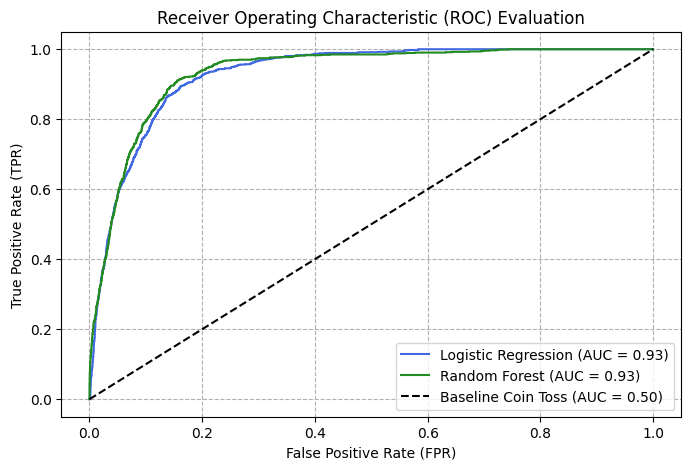

     RANDOM FOREST PERFORMANCE CLASSIFICATION     
Overall Model F1-Score: 0.3893

Confusion Matrix Layout:
[[7212   91]
 [ 687  248]]

Classification Metrics Breakdown:
                 precision    recall  f1-score   support

No Subscription       0.91      0.99      0.95      7303
     Subscribed       0.73      0.27      0.39       935

       accuracy                           0.91      8238
      macro avg       0.82      0.63      0.67      8238
   weighted avg       0.89      0.91      0.89      8238



In [10]:
#STEP 4: DIAGNOSTIC ROC MATRIX GENERATION
# Collect cross-validation assignment probabilities
lr_probs = lr_model.predict_proba(X_test)[:, 1]
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# Calculate true/false vectors across operational thresholds
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

# Plot performance curves
plt.figure(figsize=(8, 5))
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr_probs):.2f})', color='royalblue')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_probs):.2f})', color='forestgreen')
plt.plot([0, 1], [0, 1], 'k--', label='Baseline Coin Toss (AUC = 0.50)')
plt.title('Receiver Operating Characteristic (ROC) Evaluation')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--')
plt.show()

# Display performance values for the stronger model (Random Forest)
rf_preds = rf_model.predict(X_test)
print("     RANDOM FOREST PERFORMANCE CLASSIFICATION     ")
print(f"Overall Model F1-Score: {f1_score(y_test, rf_preds):.4f}")
print("\nConfusion Matrix Layout:")
print(confusion_matrix(y_test, rf_preds))
print("\nClassification Metrics Breakdown:")
print(classification_report(y_test, rf_preds, target_names=['No Subscription', 'Subscribed']))


Initializing SHAP TreeExplainer engine...

--- Generation Complete: Displaying Global Feature Importances ---


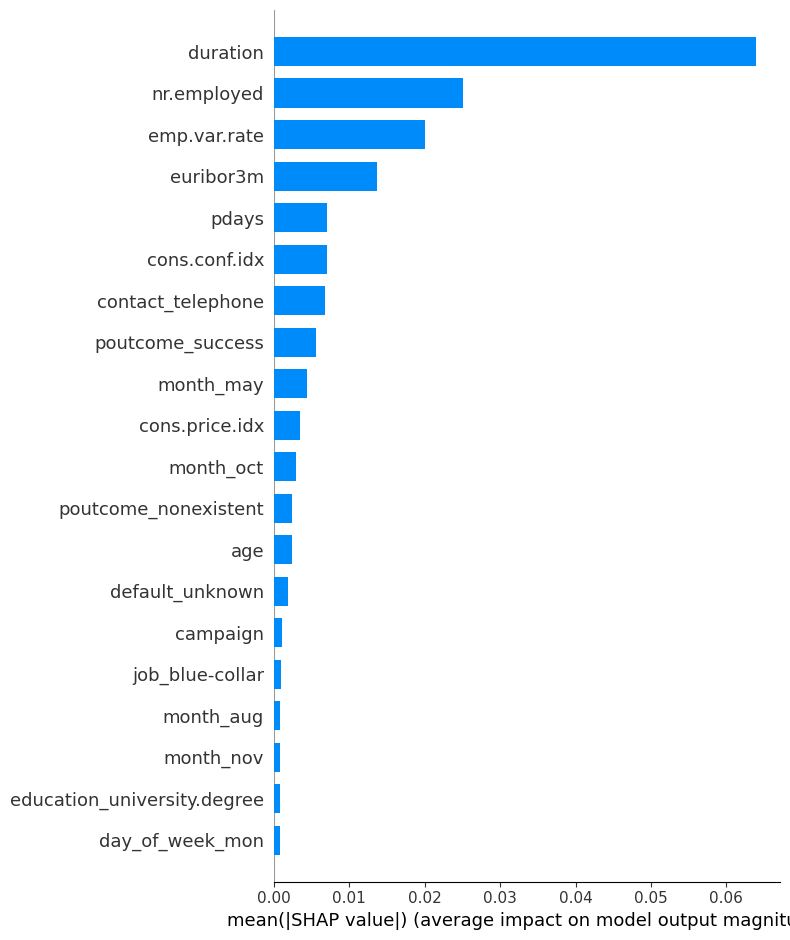


--- Displaying Local Feature Directional Impact ---


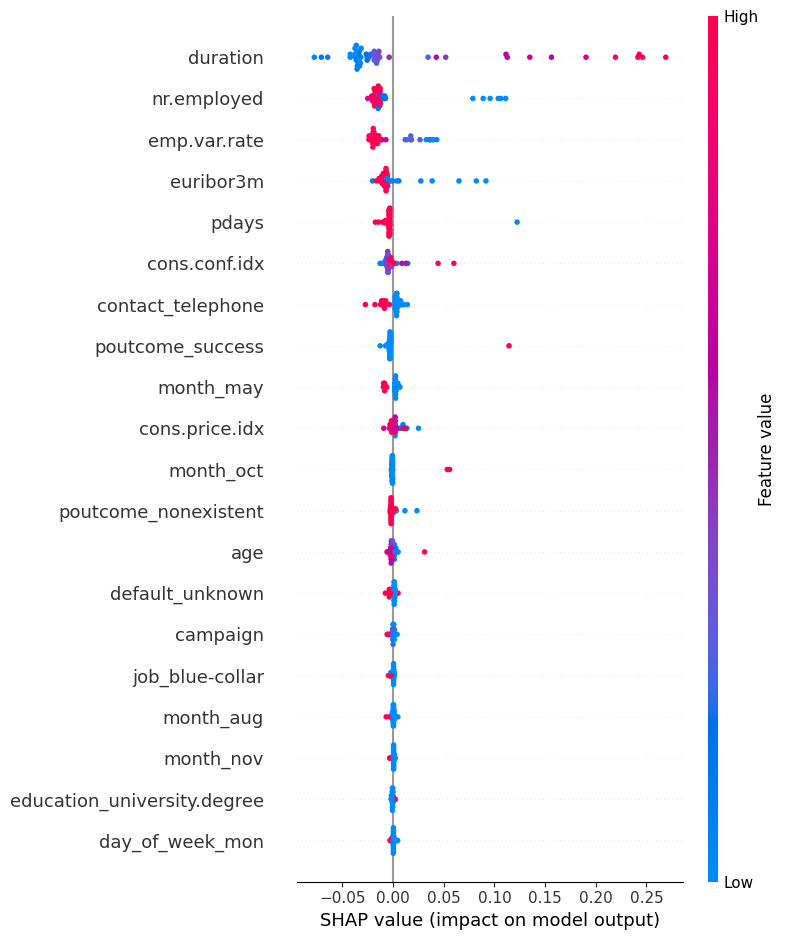

In [13]:
# =====================================================================
# STEP 5: EXPLAINABLE AI (XAI) EVALUATION CARD
# =====================================================================
print("\nInitializing SHAP TreeExplainer engine...")

# Use the traditional tree explainer configuration
explainer = shap.TreeExplainer(rf_model)

# Grab a small slice of test rows to compute weights quickly
X_sample = X_test.iloc[:50]
shap_values_raw = explainer.shap_values(X_sample)

# Note: For binary classification, TreeExplainer returns a list of two arrays:
# index 0 is for class 'No Subscription', index 1 is for 'Subscribed'.
# We extract index 1 to explain what DRIVES subscriptions.
if isinstance(shap_values_raw, list):
    shap_values_to_plot = shap_values_raw[1]
else:
    # On some sklearn updates, it returns a 3D matrix where the last axis represents the class
    shap_values_to_plot = shap_values_raw[:, :, 1] if len(shap_values_raw.shape) == 3 else shap_values_raw

print(f"\n--- Generation Complete: Displaying Global Feature Importances ---")
# 1. Classical Bar Plot: Shows the absolute power of each feature
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values_to_plot, X_sample, plot_type="bar")

print(f"\n--- Displaying Local Feature Directional Impact ---")
# 2. Classical Dot Plot: Shows direction (High values = red, Low values = blue)
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values_to_plot, X_sample)